# Введение
Этот ноутбук посвящен анализу данных и поиску лучшей модели для задачи сегментации глиом

### Источник и состав данных

Для работы используются открытые наборы данных:

1) **Medical Segmentation Decathlon (MSD) - Brain Tumour (Task01):**
- 484 случая.
- Формат 4D NIfTI (4 модальности в одном файле).
- Ориентация RAS.

2) **UPENN-GBM:**
- 147 случаев.
- Формат 3D NIfTI (каждая модальность — отдельный файл).
- Ориентация LPS.

В обоих датасетах представлены модальности: **T1, T1ce, T2, FLAIR**.

Цель — сегментация трех областей: **TC (Tumor Core, ядро)**, **ET (Enhancing Tumor, активная часть)**, **WT (Whole Tumor, вся опухоль**, т.е TC + ET + перитуморальный отёк).

Labels (метки):
*   **0**: Фон (здоровая ткань).
*   **1**: Перитуморальный отёк (ED).
*   **2**: Некроз и неконтрастное ядро (NCR/NET).
*   **3**: Активная часть опухоли (ET).

Соотношение меток с клиническими компонентами:
1. WT (Whole Tumor) = Label 1 + Label 2 + Label 3 (вся область поражения, включая отёк).
2. TC (Tumor Core) = Label 2 + Label 3 (все ядро целиком).
3. ET (Enhancing Tumor) = только Label 3.

# 1. Загрузка и очистка данных

Пайплайн подготовки данных реализован в `scripts/prepare_data.py`. Он включает в себя следующие шаги:
1. Проверка целостности NIfTI файлов: `validate_integrity` подтверждает, что все файлы в raw-директориях читаются без ошибок
2. Проверка соответствия:  `validate_msd_consistency` и `validate_upenn_consistency` проверяют наличие пар "снимок-маска" для каждого пациента и их геометрическое соответствие.
3. Иморт датасета MSD в директорию data/processed: функция `import_msd()`
4. Приведение UPENN в единый формат с MSD `prepare_upenn_dataset()`с сохранением в data/processed:
- маппинг модальностей в соответствие с MSD;
- cтэкинг 3D-модальностей в один 4D NIfTI файл;
- переориентация из LPS к стандарту RAS;
- метки UPENN {1, 2, 4} перекодированы в стандарт BraTS/MSD {1, 2, 3}.
5. Сбор метаданных: `collect_metadata()` агрегирует геометрические параметры (размеры, спейсинг) и хеши всех случаев в единый файл `data/processed/metadata.csv` для последующего статистического анализа.
6. Поиск дубликатов: `validate_duplicates` проверяет отсутствие дублирующих записей (через MD5-хеширование модальности FLAIR) внутри и между датасетами.
7. Финальная верификация: Функция `validate_processed_dataset` проверяет уже обработанные (processed) данные на соответствие RAS-ориентации, совпадение аффинных матриц и корректность маппинга меток {0, 1, 2, 3}.

Размер предобработанных данных:
- MSD_BrainTumour: ~4.4 Гб
- UPENN-GBM: ~1.4 Гб

 Данные версионируются через DVC и также хранятся в удаленном S3-совместимом хранилище (MinIO), что позволяет использовать их в Colab, где будет проводится обучение модели.

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nibabel as nib
from nilearn import plotting

# Загрузка метаданных
# Если вы запускаете ноутбук из папки notebooks/, используйте '../'
metadata_path = '../data/processed/metadata.csv'
if not os.path.exists(metadata_path):
    # Если запуск из корня проекта
    metadata_path = 'data/processed/metadata.csv'

df = pd.read_csv(metadata_path)
print(f"Загружено {len(df)} случаев из {df['dataset'].unique()}")


Загружено 631 случаев из <StringArray>
['MSD_BrainTumour', 'UPENN-GBM']
Length: 2, dtype: str


# 2. Анализ данных

### 2.1. Анализ геометрических параметров
Важно проверить, имеют ли снимки одинаковое разрешение и размеры вокселей. Различия в спейсинге могут потребовать ресемплирования.

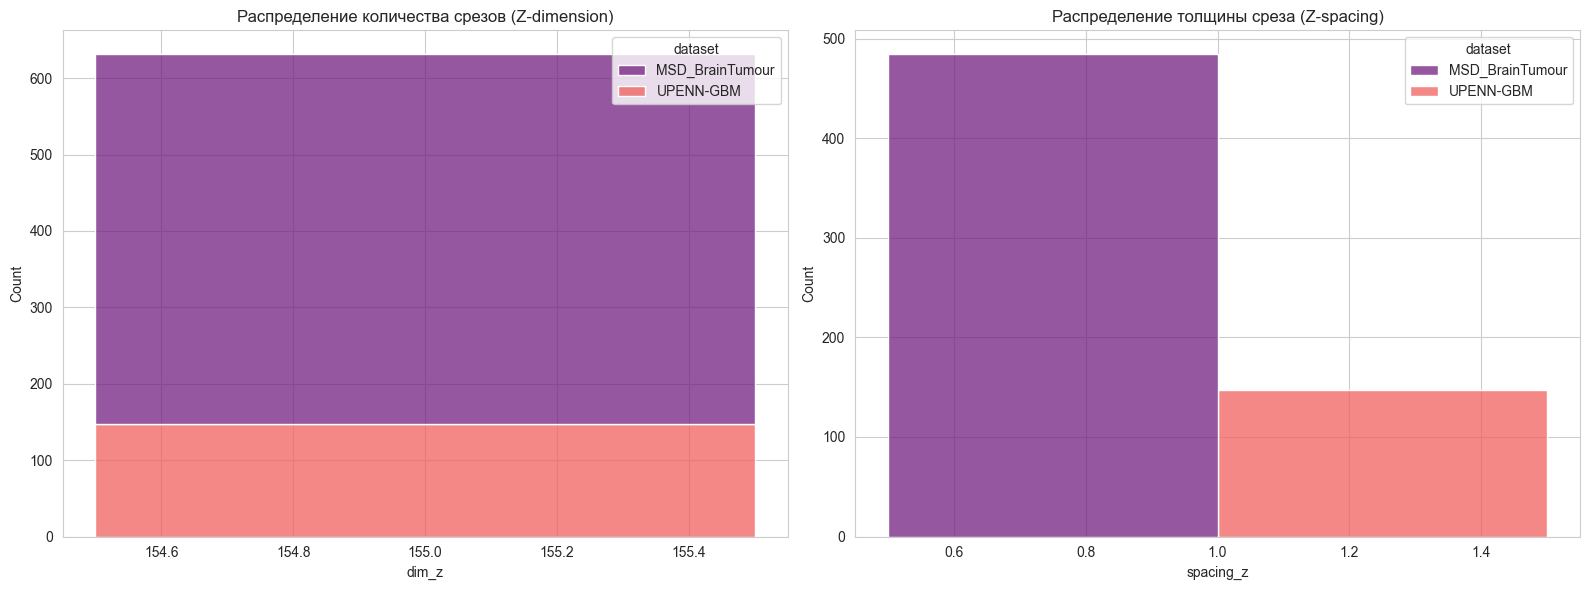

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Размеры по Z (глубина снимка)
sns.histplot(data=df, x='dim_z', hue='dataset', multiple='stack', ax=axes[0], palette='magma')
axes[0].set_title('Распределение количества срезов (Z-dimension)')

# Спейсинг по Z
sns.histplot(data=df, x='spacing_z', hue='dataset', multiple='dodge', ax=axes[1], palette='magma')
axes[1].set_title('Распределение толщины среза (Z-spacing)')

plt.tight_layout()
plt.show()

Выводы.

В данном случае гистограммы представляют собой одиночные пики, что подтверждает, что все 631 случай (как из MSD, так и из UPENN-GBM) имеют абсолютно идентичные геометрические характеристики:
- Размеры (Dimensions): $240 \times 240 \times 155$ вокселей.
- Спейсинг (Spacing): $1.0 \times 1.0 \times 1.0$ мм (изотропное разрешение).

=> Можно использовать фиксированный размер патча (например, 128x128x128) для обучения модели без риска искажения анатомии

Для будущих клинических данных в пайплайн нужно будет добавить блок автоматического приведения к указанному резмеру и спейсингу
=> **Ресемплирование**

### 2.2. Анализ распределения интенсивностей
МРТ снимки могут иметь разные диапазоны интенсивностей в зависимости от сканера и настроек. Посмотрим на распределение интенсивностей (без фона) для типичных случаев из обоих датасетов.

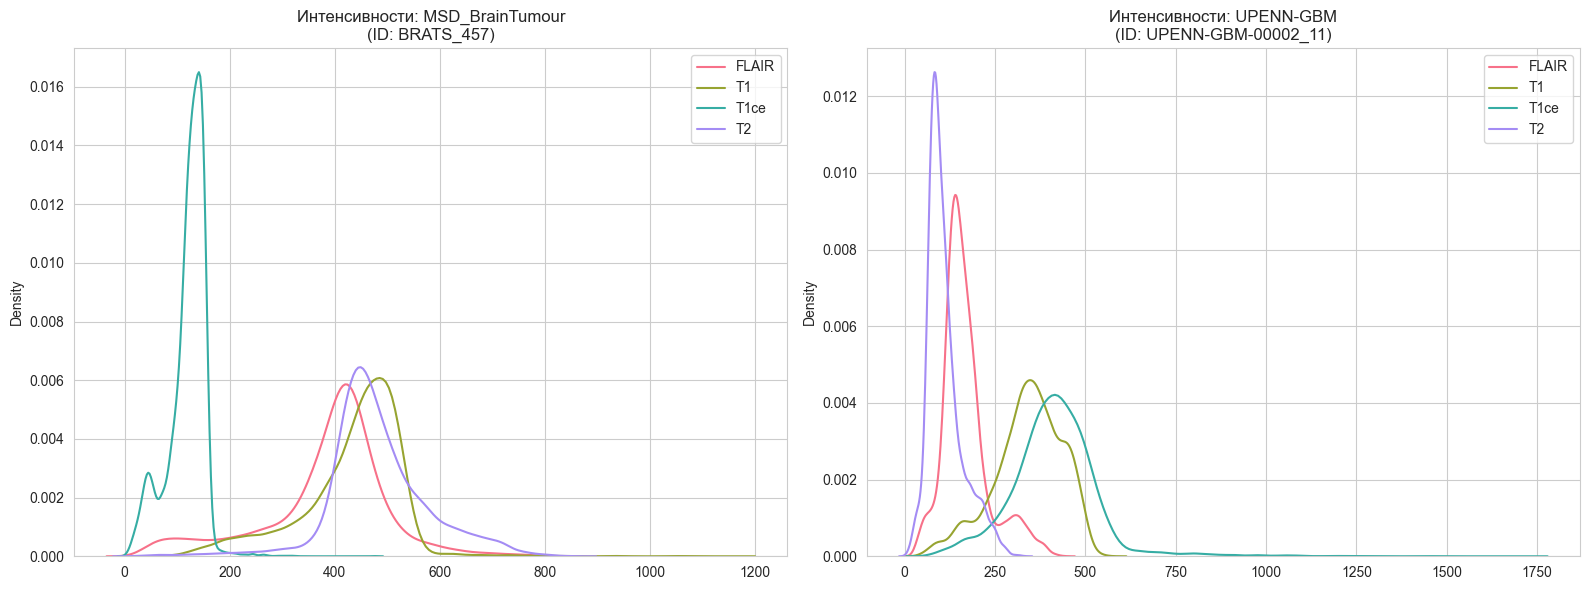

In [4]:
def plot_intensities(df_subset, ax):
    case = df_subset.iloc[0]
    ds = case['dataset']
    pid = case['patient_id']

    # Путь к файлу (учитываем возможный запуск из разных папок)
    path = f"../data/processed/{ds}/imagesTr/{pid}.nii.gz"
    if not os.path.exists(path):
        path = f"data/processed/{ds}/imagesTr/{pid}.nii.gz"

    img = nib.load(path).get_fdata()
    modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
    colors = sns.color_palette("husl", 4)

    for i in range(4):
        data = img[..., i].flatten()
        data = data[data > 0] # Убираем фон (0)
        # Берем подвыборку для ускорения отрисовки KDE
        if len(data) > 10000:
            data = np.random.choice(data, 10000, replace=False)
        sns.kdeplot(data, ax=ax, label=modalities[i], color=colors[i])

    ax.set_title(f'Интенсивности: {ds}\n(ID: {pid})')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_intensities(df[df['dataset'] == 'MSD_BrainTumour'], axes[0])
plot_intensities(df[df['dataset'] == 'UPENN-GBM'], axes[1])
plt.tight_layout()
plt.show()

Выводы.
- Общая форма распределений для MSD и UPENN выглядит сопоставимой.
- Нет абсолютной шкалы яркости, значения интенсивностей могут варьироваться от 0 до нескольких тысяч => в пайплайне обязательна **нормализация + желательно предварительно сделать clipping** (отсечение) по 0.5 и 99.5 перцентилям.
- Обязательно использование **gamma augmentation** (случайное изменение контрастности)

и### 2.3. Анализ дисбаланса классов
Оценим дисбаланс между здоровой тканью и патологией.

In [5]:
# Рассчитаем физические объемы (в мм^3)
df['voxel_volume'] = df['spacing_x'] * df['spacing_y'] * df['spacing_z']
for i in range(1, 4):
    df[f'label_{i}_volume_mm3'] = df[f'label_{i}_voxels'] * df['voxel_volume']
df['total_tumor_volume_mm3'] = df['total_tumor_voxels'] * df['voxel_volume']

# Доля опухоли от всего объема снимка
df['tumor_fraction_%'] = (df['total_tumor_voxels'] / (df['dim_x'] * df['dim_y'] * df['dim_z'])) * 100

print(f"Средняя доля опухоли в объеме снимка: {df['tumor_fraction_%'].mean():.2f}%")
df[['dataset', 'patient_id', 'total_tumor_volume_mm3', 'tumor_fraction_%']].head()

Средняя доля опухоли в объеме снимка: 1.09%


,dataset,patient_id,total_tumor_volume_mm3,tumor_fraction_%
0,MSD_BrainTumour,BRATS_457,73791.0,0.826512
1,MSD_BrainTumour,BRATS_306,32051.0,0.358994
2,MSD_BrainTumour,BRATS_206,266936.0,2.989875
3,MSD_BrainTumour,BRATS_449,131589.0,1.473891
4,MSD_BrainTumour,BRATS_318,95627.0,1.071091


Выводы.

Исходя из выявленного экстремального дисбаланса (опухоль занимает лишь ~1.5% объёма), для обучения рекомендуется:
- Применить **crop to non-zero** в препроцессинге данных и **foreground over-sampling** при подготовке патчей, чтобы минимизировать влияние доминирующего фона и сфокусировать обучение на патологических зонах.
- Использовать комбинированную функцию потерь **Dice + Cross-Entropy (CE)**, чтобы модель уделяла достаточно внимания малым, но критически важным структурам.

### 2.4. Анализ объемов опухоли
Сравним распределение объемов опухоли в двух датасетах.

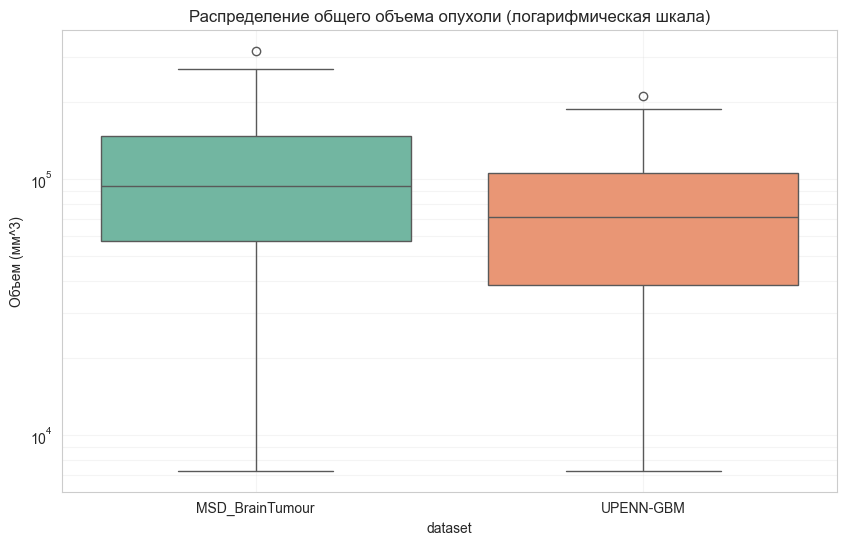

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dataset', y='total_tumor_volume_mm3', hue='dataset', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Распределение общего объема опухоли (логарифмическая шкала)')
plt.ylabel('Объем (мм^3)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Выводы.
- Распределения объемов опухолей в датасетах MSD и UPENN-GBM визуально схожи (медианы и межквартильные размахи находятся в одном диапазоне).
- Наличие случаев в нижней части графика (нижние «усы» и выбросы с малым объемом) указывает на наиболее сложные для сегментации примеры.

### 2.5. Дисбаланс компонентов опухоли


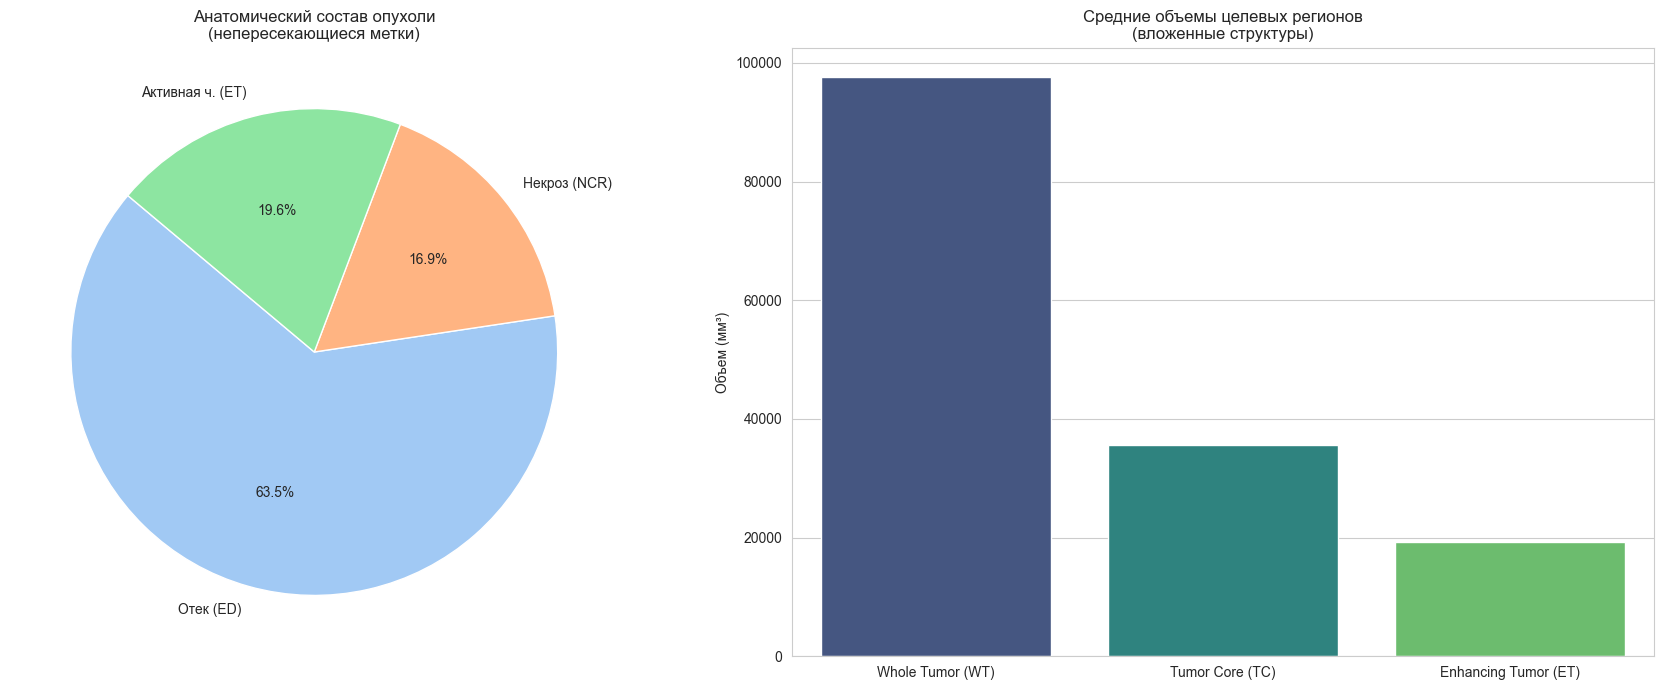

In [7]:
# 1. Расчет объемов клинических регионов (вложенных)
df['WT_vol'] = df['label_1_volume_mm3'] + df['label_2_volume_mm3'] + df['label_3_volume_mm3']
df['TC_vol'] = df['label_2_volume_mm3'] + df['label_3_volume_mm3']
df['ET_vol'] = df['label_3_volume_mm3']

# 2. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Слева: Состав опухоли (Labels) - круговая диаграмма
labels_stats = df[['label_1_volume_mm3', 'label_2_volume_mm3', 'label_3_volume_mm3']].mean()
axes[0].pie(labels_stats, labels=['Отек (ED)', 'Некроз (NCR)', 'Активная ч. (ET)'],
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Анатомический состав опухоли\n(непересекающиеся метки)')

# Справа: Средние объемы регионов (Regions) - столбчатая диаграмма
region_stats = df[['WT_vol', 'TC_vol', 'ET_vol']].mean()
sns.barplot(x=['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)'],
            y=region_stats.values, ax=axes[1], hue=['WT', 'TC', 'ET'], palette='viridis', legend=False)
axes[1].set_title('Средние объемы целевых регионов\n(вложенные структуры)')
axes[1].set_ylabel('Объем (мм³)')

plt.tight_layout()
plt.show()

Выводы.

- Самый клинически важный компонент — активная, накапливающая контраст опухоль (ET) — является одним из самых малых по объему => **использование комбинированной лосс-функции (Dice + СE)**.

### 2.6. Анализ аномалий и топологическая проверка
Для обеспечения высокого качества обучения проведена проверка разметки на наличие технических ошибок и соблюдение биологической иерархии регионов.

In [8]:
# 1. Поиск кейсов с отсутствующими компонентами
missing_et = df[df['label_3_voxels'] == 0]
missing_ncr = df[df['label_2_voxels'] == 0]
print(f"Кейсов без активной части (ET): {len(missing_et)}")
print(f"Кейсов без некротического ядра (NCR): {len(missing_ncr)}")

# 2. Поиск экстремально малых компонентов (потенциальный шум)
# Возьмем порог в 50 вокселей (~0.05 см^3)
noisy_et = df[(df['label_3_voxels'] > 0) & (df['label_3_voxels'] < 50)]
print(f"Кейсов с экстремально малым ET (<50 вокселей): {len(noisy_et)}")

# 3. Топологическая проверка
# В системе непересекающихся меток вложенность ET ⊂ TC ⊂ WT гарантирована.
# Проверим, нет ли случаев с ET, но без общего ядра TC (что было бы ошибкой)
topo_errors = df[(df['label_3_voxels'] > 0) & ((df['label_2_voxels'] + df['label_3_voxels']) == 0)]
print(f"Топологических ошибок обнаружено: {len(topo_errors)}")

Кейсов без активной части (ET): 12
Кейсов без некротического ядра (NCR): 1
Кейсов с экстремально малым ET (<50 вокселей): 4
Топологических ошибок обнаружено: 0


Выводы.
- Анатомическая логика вложенности регионов полностью сохранена (ET внутри TC, а TC внутри WT) => **Region-based сегментация**
- Не во всех случаях присутствуют все три компонента опухоли, поэтому модель должна уметь корректно предсказывать «пустые» каналы для отсутствующих структур, не пытаясь найти их там, где их нет => **Sigmoid-функция**
- Были найдены случаи с экстремально малыми фрагментами компонентов (менее 50 вокселей), которые могут соотвествовать артефактам ручной разметки =>  **Connected Component Analysis (CCA)** для борьбы с «ложноположительными аномалиями» в финальном пайплайне, использование на тесте метрики **Hausdorff Distance 95% (HD95)**(чувствительна к outlier‑ошибкам).

### 2.7 Визуализация
Для подтверждения точности аннотаций и корректности совмещения модальностей после предобработки проведена визуализация типичных и граничных случаев.

Золотой стандарт (3 проекции + детальные модальности):


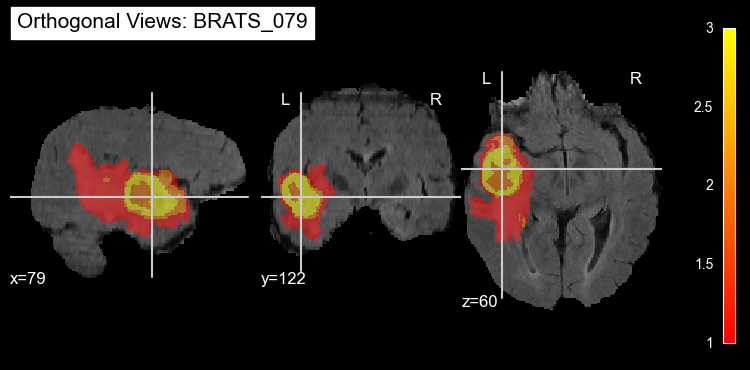

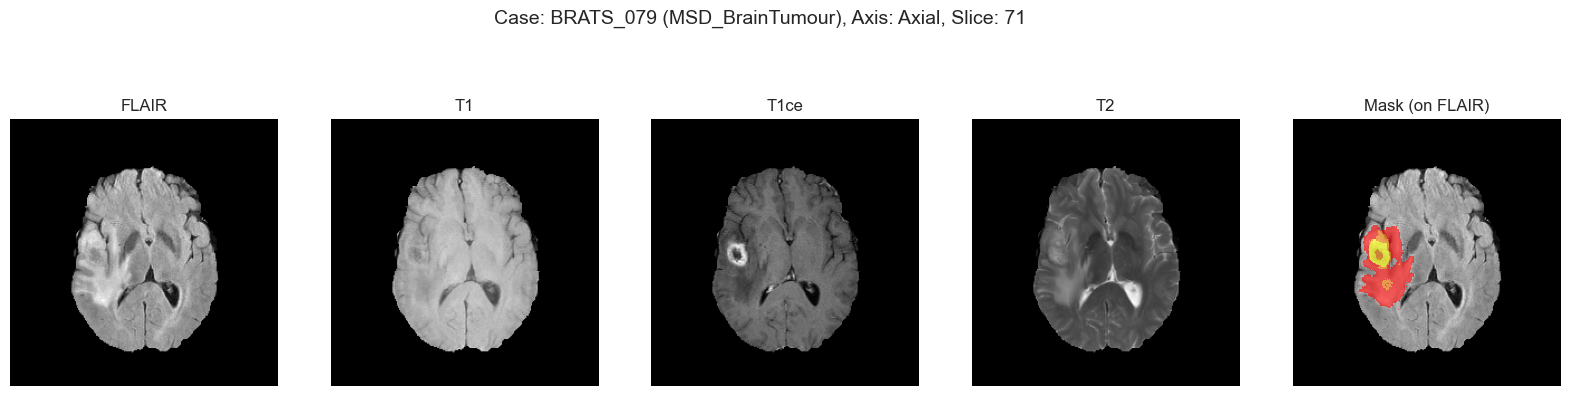

Атипичный случай (малый объем, Сагиттальная проекция):


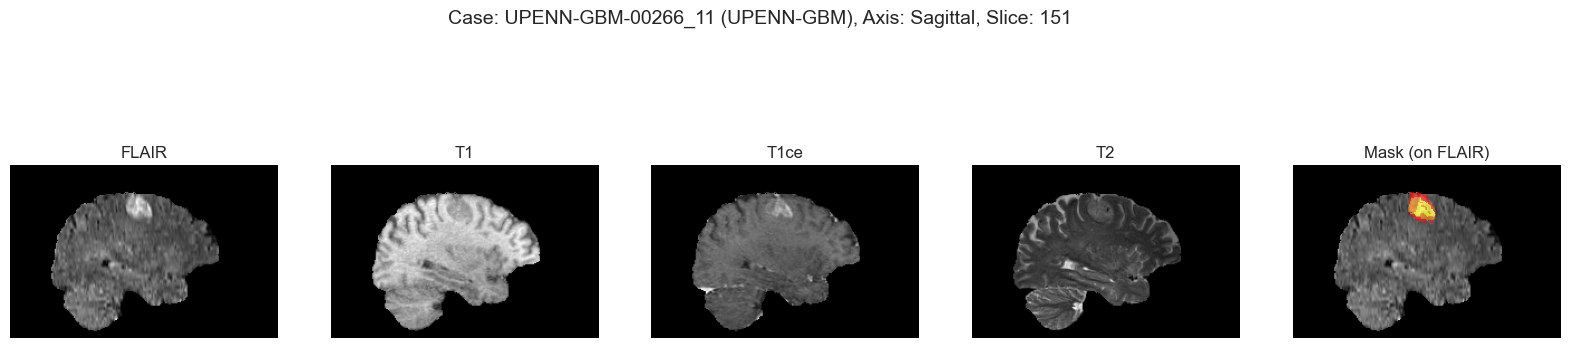

Атипичный случай (большой объем, Корональная проекция):


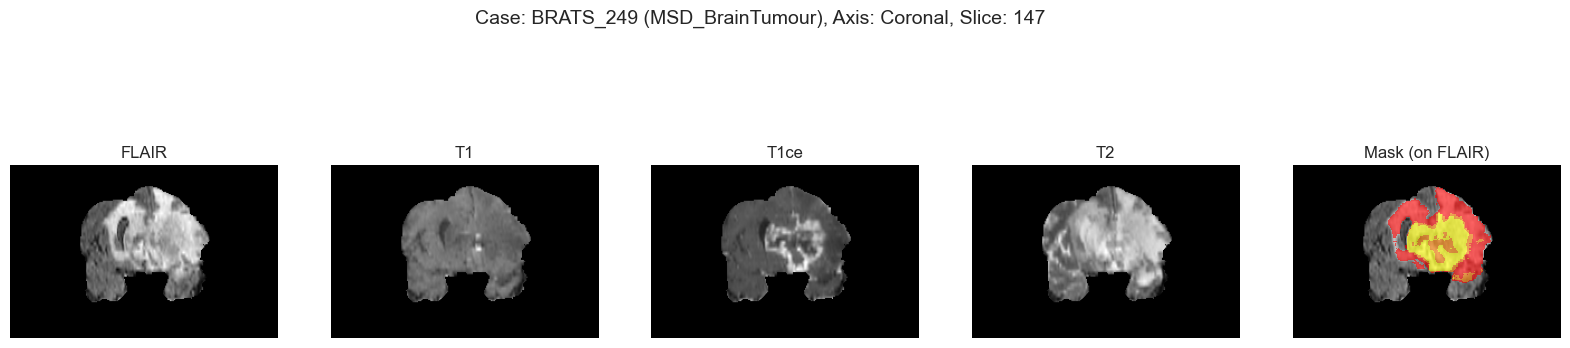

In [12]:
def visualize_case(case_id, dataset, axis=2):
    path_img = f"../data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
    path_lbl = f"../data/processed/{dataset}/labelsTr/{case_id}.nii.gz"
    if not os.path.exists(path_img):
        path_img = f"data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
        path_lbl = f"data/processed/{dataset}/labelsTr/{case_id}.nii.gz"

    if not os.path.exists(path_img):
        print(f"Error: File not found {path_img}")
        return

    img = nib.load(path_img).get_fdata()
    lbl = nib.load(path_lbl).get_fdata()

    # Находим срез с максимальной площадью опухоли для выбранной оси
    sum_axes = tuple([i for i in range(3) if i != axis])
    slice_idx = np.argmax(np.sum(lbl > 0, axis=sum_axes))

    # Подготовка срезов
    if axis == 0: # Sagittal (YZ)
        slicer = lambda data: data[slice_idx, :, :]
        axis_name = "Sagittal"
    elif axis == 1: # Coronal (XZ)
        slicer = lambda data: data[:, slice_idx, :]
        axis_name = "Coronal"
    else: # Axial (XY)
        slicer = lambda data: data[:, :, slice_idx]
        axis_name = "Axial"

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    modalities = ['FLAIR', 'T1', 'T1ce', 'T2']

    for i in range(4):
        axes[i].imshow(slicer(img[..., i]).T, cmap='gray', origin='lower')
        axes[i].set_title(modalities[i])
        axes[i].axis('off')

    # Отображаем маску на фоне FLAIR
    axes[4].imshow(slicer(img[..., 0]).T, cmap='gray', origin='lower')
    mask_data = slicer(lbl)
    mask = np.ma.masked_where(mask_data == 0, mask_data)
    axes[4].imshow(mask.T, cmap='autumn', alpha=0.6, origin='lower', interpolation='none')
    axes[4].set_title('Mask (on FLAIR)')
    axes[4].axis('off')

    plt.suptitle(f"Case: {case_id} ({dataset}), Axis: {axis_name}, Slice: {slice_idx}", fontsize=14)
    plt.show()

def visualize_case_ortho(case_id, dataset):
    path_img = f"../data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
    path_lbl = f"../data/processed/{dataset}/labelsTr/{case_id}.nii.gz"
    if not os.path.exists(path_img):
        path_img = f"data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
        path_lbl = f"data/processed/{dataset}/labelsTr/{case_id}.nii.gz"

    if not os.path.exists(path_img):
        print(f"Error: File not found {path_img}")
        return

    img_nii = nib.load(path_img)
    lbl_nii = nib.load(path_lbl)

    # Выделяем FLAIR (канал 0) для фона
    from nilearn.image import index_img
    flair_nii = index_img(img_nii, 0)

    plotting.plot_roi(lbl_nii, bg_img=flair_nii,
                     title=f"Orthogonal Views: {case_id}",
                     display_mode='ortho',
                     cut_coords=None,
                     cmap='autumn',
                     alpha=0.5)
    plotting.show()

# Визуализация примеров
print("Золотой стандарт (3 проекции + детальные модальности):")
visualize_case_ortho('BRATS_079', 'MSD_BrainTumour')
visualize_case('BRATS_079', 'MSD_BrainTumour', axis=2)

print("Атипичный случай (малый объем, Сагиттальная проекция):")
visualize_case('UPENN-GBM-00266_11', 'UPENN-GBM', axis=0)

print("Атипичный случай (большой объем, Корональная проекция):")
visualize_case('BRATS_249', 'MSD_BrainTumour', axis=1)

Выводы.
- Маски во всех проверенных случаях (включая трансформированный UPENN-GBM) точно соответствуют анатомическим границам опухоли.
- Модальность T1ce критична для ET, а FLAIR — для определения границ отека.
- Малые очаги требуют особого внимания при обучении => использование функции потерь **CE**, применение **эластичных деформаций**, **Test-Time Augmentation (TTA)**.

### Формирование выборки и стратегия валидации

Набор UPENN-GBM после предобработки полностью совместим с MSD, что позволяет использовать его как независимый тестовый набор для проверки обобщающей способности модели.

### Алгоритм формирования выборки:
1. Обучающая и внутренняя валидационная выборки: Используется датасет MSD (484 случая).
2. Внешняя тестовая выборка: Используется датасет UPENN-GBM (147 случаев).

### Стратегия валидации:
- ~~K-Fold Cross-Validation (k=5) на данных MSD. Это обеспечит робастную оценку модели на ограниченном объеме данных.~~ не удалось реализовать из-за ограниченности ресурсов
- Стратификация: При разделении на фолды будет учитываться распределение объемов опухолей (биннинг по объему), чтобы в каждый фолд попали как типичные, так и редкие случаи.

### Выводы для моделирования

1. **Препроцесссинг данных**: сrop to non-zero, ресемплирование, поканальная нормализация (Z-score), при необходимости final pad/crop (чтобы подогнать размер под архитектуру)
2. **Формирование таргетов**: Region-based стратегия c Sigmoid функцией
3. **Формирование батчей**: фиксированный размер патчей (например, 128x128x128), применение Foreground Over-sampling.
4. **Аугментация**:  эластичные деформации + gamma correction + spatial transforms (повороты, масштабирование, зеркальное отображение).
5. **Loss-функция**: Dice Loss + CE.
6. **Стратегия валидации**: 5-Fold cross-validation на данных MSD, стратицикация по объёму опухоли.
7. **Внешнее тестирование**: оценка на датасете UPENN-GBM, метрики Dice (точность объема) и HD95 (точность границ и отсутствие выбросов).
8. **Инференс**: TTA.
9. **Постпроцессинг**: CСА.

# 3. Модели

Для текущего baseline-этапа были выбраны две архитектуры разной сложности:

1. **Простая модель: `UNet3D`** (`configs/unet3d.yaml`).
- CNN encoder-decoder архитектура без transformer-блоков.
- Используется как основной baseline: она быстрее обучается, проще интерпретируется и подходит для проверки корректности всего пайплайна.
- В текущем эксперименте модель обучалась до `300` эпох.

2. **Усложнённая модель: `Swin UNETR`** (`configs/swin_unetr.yaml`).
- Более тяжёлая transformer-based архитектура с self-attention и pretrained encoder.
- Используется как сильный кандидат, который потенциально лучше учитывает глобальный 3D-контекст.
- В текущем эксперименте обучение было настроено до `600` эпох, но остановилось раньше из-за aggressive early stopping, поэтому результат рассматривается как предварительный.

Также была предпринята попытка обучить ещё более ресурсоёмкую архитектуру **`Swin DER`** (`configs/swin_der.yaml`). Однако уже на пробном запуске стало понятно, что модель слишком тяжёлая для доступного вычислительного бюджета: одна эпоха занимала около `38` минут. При таком времени обучения полноценный запуск даже на `300` эпох занял бы примерно `190` часов, поэтому модель не была доведена до полноценного обучения и не включалась в финальное сравнение метрик.

Обе модели сравниваются на одном и том же fold/split, чтобы различия в метриках отражали поведение архитектур, а не различие в составе validation-набора.

In [7]:
from pathlib import Path

import pandas as pd
import torch
import matplotlib.pyplot as plt

from scripts.utils.data import load_config
from models import get_model


BASE_CONFIG_PATH = "../configs/base.yaml"
MODEL_CONFIGS = {
    "UNet3D baseline": "../configs/unet3d.yaml",
    "Swin UNETR": "../configs/swin_unetr.yaml",
}


def count_model_parameters(model_name, config):
    """Считает число параметров модели для демонстрации различия сложности архитектур."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_model(model_name, config).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_params, trainable_params


model_rows = []
for display_name, config_path in MODEL_CONFIGS.items():
    cfg = load_config(config_path, base_config_path=BASE_CONFIG_PATH)
    total_params, trainable_params = count_model_parameters(cfg["model_name"], cfg)
    model_rows.append(
        {
            "model": display_name,
            "config": config_path,
            "model_name": cfg["model_name"],
            "max_epochs": cfg["max_epochs"],
            "batch_size": cfg["batch_size"],
            "lr": cfg["lr"],
            "img_size": cfg["img_size"],
            "transfer_learning": cfg.get("transfer_learning", False),
            "deep_supervision": cfg.get("deep_supervision", False),
            "total_params_m": round(total_params / 1_000_000, 2),
            "trainable_params_m": round(trainable_params / 1_000_000, 2),
        }
    )

models_summary = pd.DataFrame(model_rows)
models_summary


,model,config,model_name,max_epochs,batch_size,lr,img_size,transfer_learning,deep_supervision,total_params_m,trainable_params_m
0,UNet3D baseline,../configs/unet3d.yaml,unet3d,300,4,0.0001,"[128, 128, 128]",False,False,5.93,5.93
1,Swin UNETR,../configs/swin_unetr.yaml,swin_unetr,600,2,0.0002,"[128, 128, 128]",True,True,62.19,62.19


### Вывод по выбору моделей

`UNet3D` выбран как **простая baseline-модель**, потому что он позволяет быстро проверить корректность preprocessing, transforms, loss-функции, validation loop и логирования метрик.

`Swin UNETR` выбран как **усложнённая модель**, потому что она использует transformer encoder и pretrained weights, что может улучшить качество сегментации за счёт более широкого контекста, но требует больше времени обучения и более аккуратной настройки early stopping.

Ссылки на эксперименты ClearML:
- `UNet3D baseline`: https://app.clear.ml/projects/c1e5ab0781224a248adb6c5e5e884d0c/experiments/c77bce2e4aa64b029705e89dafac0512/output/execution
- `Swin UNETR`: https://app.clear.ml/projects/c1e5ab0781224a248adb6c5e5e884d0c/experiments/80526cbe816747219efa6b17b528c7d1/output/execution


# 4. Оценка метрик качества и анализ результатов

Для оценки качества сегментации используются метрики:

1. **Mean Dice** — основная метрика качества сегментации. Чем ближе к `1`, тем лучше совпадение предсказанной и истинной маски.
2. **Per-class Dice (`WT`, `TC`, `ET`)** — Dice отдельно по клиническим регионам:
   - `WT` (`Whole Tumor`) — вся область опухоли;
   - `TC` (`Tumor Core`) — ядро опухоли;
   - `ET` (`Enhancing Tumor`) — активная контрастируемая часть.
3. **Validation loss (`DiceCE`)** — вспомогательная метрика оптимизации. Чем ниже, тем лучше, но для выбора модели приоритетнее `Dice`, потому что loss не всегда напрямую отражает клиническое качество маски.

Совокупная метрика качества считается как взвешенный score:

$QualityScore = 0.7 \cdot MeanDice + 0.3 \cdot MeanRegionDice$

где:

$MeanRegionDice = \frac{Dice_{WT} + Dice_{TC} + Dice_{ET}}{3}$

Такой score делает основной акцент на `mean Dice`, но дополнительно учитывает равномерность качества по трём клиническим регионам.


In [9]:
import pandas as pd
# Значения взяты из ClearML для лучших checkpoint'ов по Val Dice / mean_dice.
results = pd.DataFrame(
    [
        {
            "model": "UNet3D baseline",
            "clearml_task": "c77bce2e4aa64b029705e89dafac0512",
            "epochs_planned": 300,
            "best_epoch": 239,
            "mean_dice": 0.840446,
            "dice_wt": 0.905262,
            "dice_tc": 0.825425,
            "dice_et": 0.790529,
            "val_loss": 0.215411,
            "comment": "Простая CNN baseline-модель; полный запуск до 300 эпох, лучший checkpoint на эпохе 239.",
        },
        {
            "model": "Swin UNETR",
            "clearml_task": "80526cbe816747219efa6b17b528c7d1",
            "epochs_planned": 600,
            "best_epoch": 149,
            "mean_dice": 0.846023,
            "dice_wt": 0.903921,
            "dice_tc": 0.834055,
            "dice_et": 0.798453,
            "val_loss": 0.209455,
            "comment": "Transformer-based модель; лучший checkpoint на эпохе 149, запуск остановился на эпохе 204 из-за aggressive early stopping.",
        },
    ]
)


def add_quality_score(df):
    df = df.copy()
    region_cols = ["dice_wt", "dice_tc", "dice_et"]
    df["mean_region_dice"] = df[region_cols].mean(axis=1, skipna=True)
    df["quality_score"] = 0.7 * df["mean_dice"] + 0.3 * df["mean_region_dice"]
    return df


results = add_quality_score(results)
results.sort_values("quality_score", ascending=False, na_position="last")


,model,clearml_task,epochs_planned,best_epoch,mean_dice,dice_wt,dice_tc,dice_et,val_loss,comment,mean_region_dice,quality_score
1,Swin UNETR,80526cbe816747219efa6b17b528c7d1,600,149,0.846023,0.903921,0.834055,0.798453,0.209455,Transformer-based модель; лучший checkpoint на...,0.845476,0.845859
0,UNet3D baseline,c77bce2e4aa64b029705e89dafac0512,300,239,0.840446,0.905262,0.825425,0.790529,0.215411,Простая CNN baseline-модель; полный запуск до ...,0.840405,0.840434


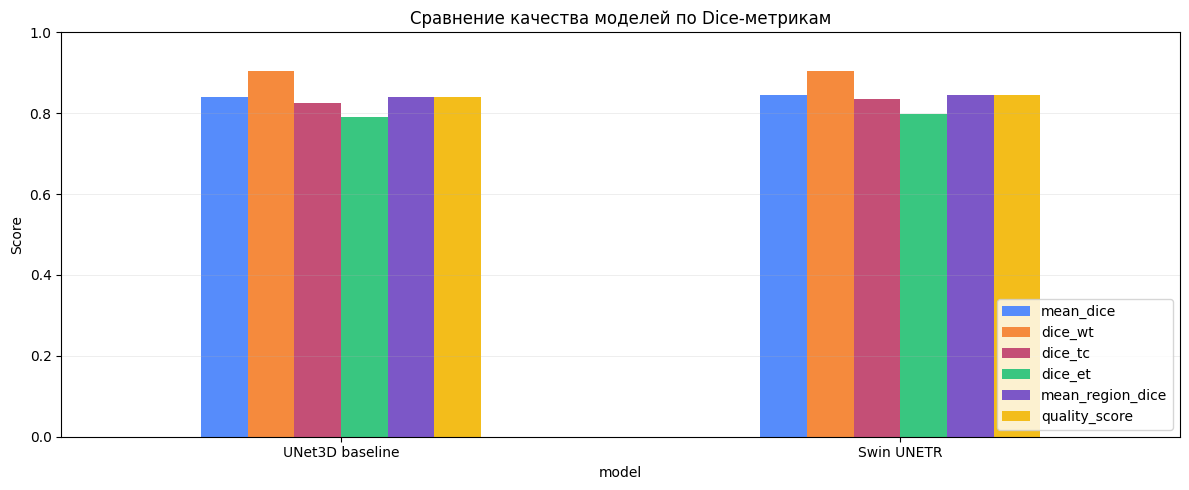

In [8]:
metric_cols = ["mean_dice", "dice_wt", "dice_tc", "dice_et", "mean_region_dice", "quality_score"]

if results[metric_cols].notna().any().any():
    ax = results.set_index("model")[metric_cols].plot(kind="bar", figsize=(12, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Сравнение качества моделей по Dice-метрикам")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


In [6]:
def summarize_best_model(results_df):
    scored = results_df.dropna(subset=["quality_score"])
    if scored.empty:
        return "Пока невозможно выбрать лучшую модель автоматически: нужно заполнить метрики из ClearML."

    best = scored.sort_values("quality_score", ascending=False).iloc[0]
    return (
        f"Лучшая модель по совокупной метрике: {best['model']} "
        f"(QualityScore={best['quality_score']:.4f}, Mean Dice={best['mean_dice']:.4f})."
    )


print(summarize_best_model(results))


Лучшая модель по совокупной метрике: Swin UNETR (QualityScore=0.8459, Mean Dice=0.8460).


### Анализ результатов

По результатам ClearML обе модели дали близкое качество на одном и том же validation split:

1. **Основное качество:** `Swin UNETR` получил немного более высокий `mean Dice` (`0.8460`) по сравнению с `UNet3D` (`0.8404`). Разница небольшая, но показывает, что усложнённая transformer-based архитектура потенциально полезна.
2. **Стабильность по классам:** `UNet3D` немного лучше по `WT` (`0.9053` против `0.9039`), но `Swin UNETR` лучше по более сложным регионам `TC` (`0.8341` против `0.8254`) и `ET` (`0.7985` против `0.7905`). Это важно, потому что `ET` является малым и клинически значимым компонентом.
3. **Validation loss:** у `Swin UNETR` ниже `val_loss` (`0.2095` против `0.2154`), что дополнительно подтверждает преимущество на текущем split.
4. **Стоимость обучения:** временные затраты на обучение `Swin UNETR` и `UNet3D` были примерно одинаковыми (3,5 минуты и 3 минуты на эпоху, соотвественно), хотя `Swin UNETR` требует больше ресурсов видеопамяти из-за transformer encoder и pretrained weights.

Предварительный вывод для сдачи baseline-части:

- `UNet3D` можно использовать как основной baseline. Планируется усилить его на следующем этапе с помощью: 1) тюнинг аугментаций 2)обучение с batch_size=2, 3) добавить deep_supervision.
- `Swin UNETR` на текущем запуске показывает чуть лучший `QualityScore`, но его результат нужно интерпретировать осторожно: лучший checkpoint был на эпохе `149`, а к моменту остановки на эпохе `204` качество уже просело. На следующем этапе имеет смысл улучшить настройку early stopping и провести обучение на большем количестве эпох (600-800).
- Планируется использовать для инференса ансамбль из улучшенной `UNet3D` и `Swin UNETR`.